In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# function to scale the y-axis data between 0 and 1
def scale_y(data):
    """
    Scales the y-axis data between 0 and 1.
    
    Parameters:
    data (array-like): The y-axis data to be scaled.
    
    Returns:
    array-like: Scaled y-axis data.
    """
    return data 
    # return (data - np.min(data)) / (np.max(data) - np.min(data))


## PART 1

This part contains plots for the mono- to multilayer regions of the stamped WS_2 sample. 

<Figure size 1000x600 with 0 Axes>

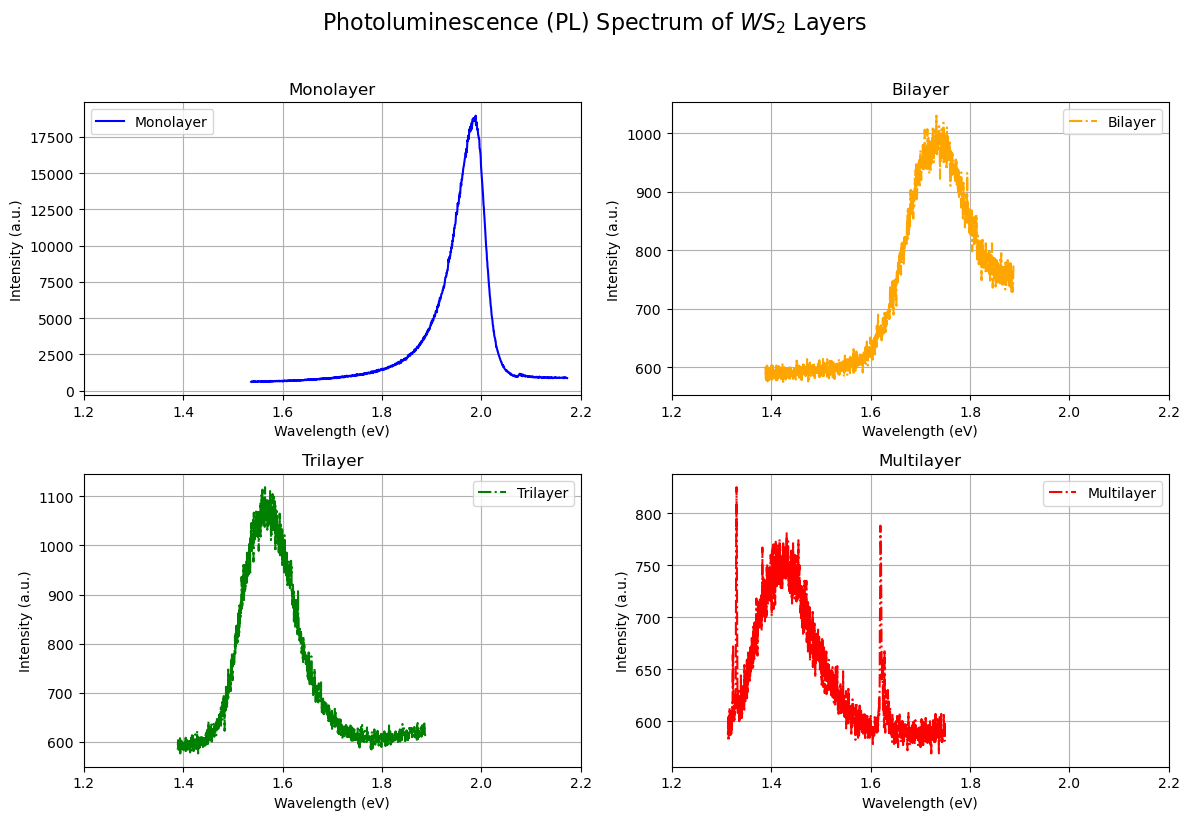

In [3]:
# accessing csv file present in a subdirectory into a pandas dataframe
# delimiter is a tab character
df_monolayer = pd.read_csv('pl-data-1/power100uw-20s 2025-06-10 14_04_02.csv', delimiter='\t')
df_bilayer = pd.read_csv('pl-data-1/power100uw-20s-bilayer 2025-06-10 14_22_36.csv', delimiter='\t')
df_tri_layer = pd.read_csv('pl-data-1/power100uw-20s-trilayer 2025-06-10 14_19_51.csv', delimiter='\t')
df_multilayer = pd.read_csv('pl-data-1/power100uw-20s-multilayer 2025-06-10 14_25_43.csv', delimiter='\t')

# print the first 5 rows of the dataframe
# print(df_monolayer.head())


# 4 subplots, one for each layer type
plt.figure(figsize=(10, 6))

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
# plot the data in the dataframe

ax[0, 0].plot(df_monolayer['Wavelength'], 
         scale_y(df_monolayer['Intensity']),
         label='Monolayer', 
         color='blue')
ax[0, 1].plot(df_bilayer['Wavelength'], 
         scale_y(df_bilayer['Intensity']),
         label='Bilayer', 
         color='orange',
         linestyle='-.')
ax[1, 0].plot(df_tri_layer['Wavelength'],
         scale_y(df_tri_layer['Intensity']),
         label='Trilayer', 
         color='green',
         linestyle='-.')
ax[1, 1].plot(df_multilayer['Wavelength'],
         scale_y(df_multilayer['Intensity']),
         label='Multilayer', 
         color='red',
         linestyle='-.')

# set the x-axis to be in eV
ax[0, 0].set_xlim(1.2, 2.2)
ax[0, 1].set_xlim(1.2, 2.2)
ax[1, 0].set_xlim(1.2, 2.2)
ax[1, 1].set_xlim(1.2, 2.2)

# plotting all of them on the same plot
ax[0, 0].set_xlabel('Wavelength (eV)')
ax[0, 1].set_xlabel('Wavelength (eV)')
ax[1, 0].set_xlabel('Wavelength (eV)')
ax[1, 1].set_xlabel('Wavelength (eV)')
ax[0, 0].set_ylabel('Intensity (a.u.)')
ax[0, 1].set_ylabel('Intensity (a.u.)')
ax[1, 0].set_ylabel('Intensity (a.u.)')
ax[1, 1].set_ylabel('Intensity (a.u.)')
ax[0, 0].legend()
ax[0, 1].legend()
ax[1, 0].legend()
ax[1, 1].legend()
# set the title for each subplot
ax[0, 0].set_title('Monolayer')
ax[0, 1].set_title('Bilayer')
ax[1, 0].set_title('Trilayer')
ax[1, 1].set_title('Multilayer')
#set grid for the subplots
ax[0, 0].grid(True)
ax[0, 1].grid(True)
ax[1, 0].grid(True)
ax[1, 1].grid(True)





plt.suptitle('Photoluminescence (PL) Spectrum of $WS_2$ Layers', fontsize=16, y=1.02)
plt.subplots_adjust(hspace=0.3, wspace=0.3)
plt.tight_layout()

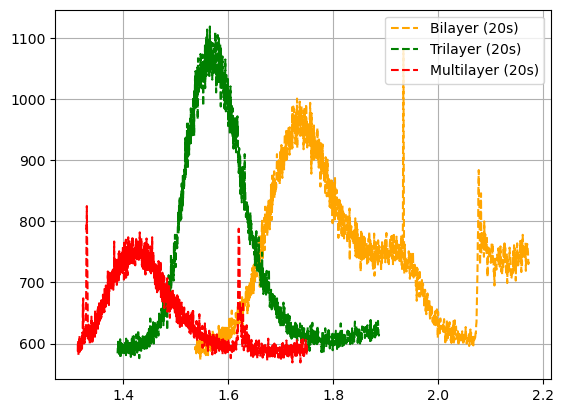

In [4]:
df_monolayer = pd.read_csv('ARL2025/pl/pl-csv/power100uw-10s 2025-06-10 14_02_16.csv', delimiter='\t')
df_bilayer2 = pd.read_csv('ARL2025/pl/pl-csv/power100uw-20s-bilayer 2025-06-10 14_08_14.csv', delimiter='\t')


# plt.plot(df_monolayer['Wavelength'],
#          scale_y(df_monolayer['Intensity']),
#          label='Monolayer (10s)', 
#          color='blue', linestyle='--')

plt.plot(df_bilayer2['Wavelength'],
         scale_y(df_bilayer2['Intensity']),
         label='Bilayer (20s)', 
         color='orange', linestyle='--')
plt.plot(df_tri_layer['Wavelength'],
         scale_y(df_tri_layer['Intensity']),
         label='Trilayer (20s)', 
         color='green', linestyle='--')
plt.plot(df_multilayer['Wavelength'],
         scale_y(df_multilayer['Intensity']),
         label='Multilayer (20s)', 
         color='red', linestyle='--')
plt.legend()
plt.grid()



In [6]:
from scipy.signal import find_peaks
import numpy as np

dfs = [df_monolayer, df_bilayer, df_tri_layer, df_multilayer]

peaks = [
    df.iloc[:, 0].values[find_peaks(df.iloc[:, 1].values)[0][
        np.argmax(df.iloc[:, 1].values[find_peaks(df.iloc[:, 1].values)[0]])
    ]]
    for df in dfs
]
peaks

[1.9878533711031023, 1.732349394633776, 1.5648059945928878, 1.3303210386857287]

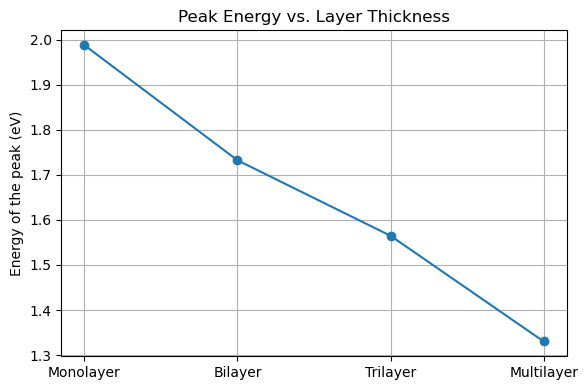

In [8]:
import matplotlib.pyplot as plt

# Define layer labels
layer_labels = ['Monolayer', 'Bilayer', 'Trilayer', 'Multilayer']

# Plot the peaks
plt.figure(figsize=(6, 4))
plt.plot(layer_labels, peaks, marker='o', linestyle='-')
plt.ylabel('Energy of the peak (eV)')
plt.title('Peak Energy vs. Layer Thickness')
plt.grid(True)
plt.tight_layout()
plt.show()


In [16]:
import numpy as np
import pandas as pd

def remove_spikes(df, window=5, z_thresh=5):
    """
    Removes narrow, high-intensity spikes in a (Wavelength, Intensity) dataframe.
    Args:
        df (pd.DataFrame): Input with two columns: Wavelength and Intensity.
        window (int): Number of neighbors to consider on each side.
        z_thresh (float): Threshold for z-score to consider a point a spike.
    Returns:
        Cleaned dataframe with spikes removed.
    """
    wl = df.iloc[:, 0].values
    intensity = df.iloc[:, 1].values
    cleaned_wl = []
    cleaned_intensity = []

    for i in range(len(intensity)):
        # Define local window
        left = max(0, i - window)
        right = min(len(intensity), i + window + 1)
        local = np.concatenate([intensity[left:i], intensity[i+1:right]])

        # Compute deviation
        local_median = np.median(local)
        local_std = np.std(local)
        if local_std == 0:
            local_std = 1e-6  # prevent division by zero

        z_score = np.abs((intensity[i] - local_median) / local_std)

        # If not a spike, keep it
        if z_score < z_thresh:
            cleaned_wl.append(wl[i])
            cleaned_intensity.append(intensity[i])

    # Return cleaned DataFrame
    return pd.DataFrame({'Wavelength': cleaned_wl, 'Intensity': cleaned_intensity})

df_cleaned_multilayer = remove_spikes(df_multilayer,
                                      window=5,
                                      z_thresh=770
                                      )


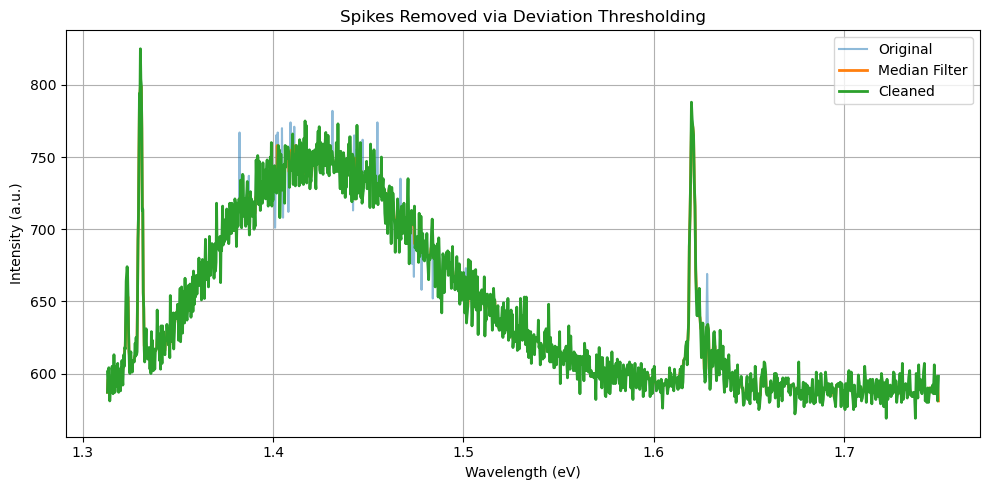